In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
from scipy.stats import norm
from scipy import stats
import matplotlib.pyplot as plt

# Question 1

In [3]:
## 1a)

# Load data
df = pd.read_excel("Assignment6Data.xlsx", sheet_name= "US bond data")
# Set datetime
df['Date'] = pd.to_datetime(df["Date"], format = "%b-%y")
# Sort oldest -> newest
df = df.sort_values("Date").reset_index(drop = True)

# Get and calculate ln yields
df["y1"] = df["SVENY01"]
df["y2"] = df["SVENY02"] 
df["y3"] = df["SVENY03"] 
df["y4"] = df["SVENY04"] 
df["y5"] = df["SVENY05"] 


# Calculate forward rates
# f_n,t = (n + 1)*y_n+1,t - n*y_n,t
df["f1"] = 2 * df["y2"] - 1 * df["y1"]
df["f2"] = 3 * df["y3"] - 2 * df["y2"]
df["f3"] = 4 * df["y4"] - 3 * df["y3"]
df["f4"] = 5 * df["y5"] - 4 * df["y4"]

# Check forward rates
df[["f1", "f2", "f3", "f4"]]

# Log HPR and excess return
# Log HPR, r_n,t+1 = n*y_n,t - (n - 1) * y_n-1,t+1

df["r2_t+1"] = 2 * df["y2"] - 1 * df["y1"].shift(-12) #Shift 12 to get 1 year back on monthly data. 
df["r3_t+1"] = 3 * df["y3"] - 2 * df["y2"].shift(-12)
df["r4_t+1"] = 4 * df["y4"] - 3 * df["y3"].shift(-12)
df["r5_t+1"] = 5 * df["y5"] - 4 * df["y4"].shift(-12)

# excess return, rx_n,t+1 = HPR - y_1,t
df["rx2_t+1"] = df["r2_t+1"] - df["y1"]
df["rx3_t+1"] = df["r3_t+1"] - df["y1"]
df["rx4_t+1"] = df["r4_t+1"] - df["y1"]
df["rx5_t+1"] = df["r5_t+1"] - df["y1"]

## Summary stats
summary_stats = pd.DataFrame()

variables = ['y1', 'y2', 'y3', 'y4', 'y5']
for var in variables:
    summary_stats[var] = df[var].describe()

forward_rates = ["f1", "f2", "f3", "f4"]
for var in forward_rates:
    summary_stats[var] = df[var].describe()

excess_returns = ["rx2_t+1", "rx3_t+1", "rx4_t+1", "rx5_t+1"]
for var in excess_returns:
    summary_stats[var] = df[var].describe()

print("Summary Statistics:")
print(summary_stats)


# Drop NAs
df = df[['y1', 'y2', 'y3', 'y4', 'y5', "f1", "f2", "f3", "f4", "rx2_t+1", "rx3_t+1", "rx4_t+1", "rx5_t+1"]]


# Analyze historical risk premia
mean_excess_returns = df[[f'rx{n}_t+1' for n in range(2,6)]].mean()
print("\nAverage Excess Returns:")
print(mean_excess_returns)

print("\nRisk Premia:")
for n in range(2,6):
    avg_rx = mean_excess_returns[f'rx{n}_t+1']
    if avg_rx > 0:
        print(f"Average excess return for maturity {n} years is positive: {avg_rx:.4f}%")
    else:
        print(f"Average excess return for maturity {n} years is negative: {avg_rx:.4f}%")



Summary Statistics:
               y1          y2          y3          y4          y5          f1  \
count  761.000000  761.000000  761.000000  761.000000  761.000000  761.000000   
mean     4.831233    5.026889    5.188446    5.326923    5.447781    5.222546   
std      3.288774    3.239417    3.173702    3.107519    3.046479    3.220642   
min      0.067800    0.113200    0.136500    0.184100    0.243100    0.089600   
25%      2.243200    2.561300    2.821800    3.015100    3.314900    2.884800   
50%      4.914200    4.934200    5.057600    5.188477    5.261629    5.133700   
75%      6.731400    6.926533    7.132918    7.228700    7.319170    7.256300   
max     16.110000   15.781500   15.574600   15.349800   15.177600   15.871300   

               f2          f3          f4     rx2_t+1     rx3_t+1     rx4_t+1  \
count  761.000000  761.000000  761.000000  749.000000  749.000000  749.000000   
mean     5.511558    5.742355    5.931212    0.380372    0.670540    0.906124   
std    

In [ ]:
df.head()

In [4]:
# 1b)

# Fama Bliss 1987 (FB)
# Store FB results
results_fb = {}

# Run Fama and Bliss regression for maturities 2 to 5
for n in range(2, 6): 
    # Dependent variable: rx_n,t+1
    dep_var = df[f"rx{n}_t+1"]
    # Independent variable: f_n,t - y1,t
    indep_var = (df[f"f{(n - 1)}"] - df["y1"])
    indep_var = sm.add_constant(indep_var)
    
    valid_data = pd.concat([dep_var, indep_var], axis=1).dropna()
    dep_var = valid_data.iloc[:, 0]
    indep_var = valid_data.iloc[:, 1:]


    # OLS
    model = sm.OLS(dep_var, indep_var).fit(cov_type='HAC', cov_kwds={'maxlags': 12}) # NW SE 12 lags (1 year)

    # Keys
    intercept_key = indep_var.columns[0] # alpha
    slope_key = indep_var.columns[1]  # beta

    # Store results
    results_fb[n] = {
        "params": model.params,
        "bse": model.bse,
        "tvalues": model.tvalues,
        "pvalues": model.pvalues,
        "rsquared": model.rsquared,
    }

    # Print results
    print()
    print(f"Fama and Bliss Regression for maturity {n}:")
    print(f"Intercept (a_n): {model.params[intercept_key]:.4f} (SE: {model.bse[intercept_key]:.4f}, p-value: {model.pvalues[intercept_key]:.4f})")
    print(f"Coefficient (b_n): {model.params[slope_key]:.4f} (SE: {model.bse[slope_key]:.4f}, p-value: {model.pvalues[slope_key]:.4f})")
    print(f"R-squared: {model.rsquared:.4f}")

#Campbell and Shiller 1991 (CS)
#Store CS results
results_cs = {}

#Run Campbell and Shiller regression for maturities 2 to 5
for n in range(2, 6):
    #Dependent variable: y_{n-1,t+1} - y_{n,t}
    dep_var = (df[f"y{n-1}"] - df[f"y{n}"].shift(12))
    
    #Independent variable: (y_{n,t} - y_{1,t}) / (n - 1)
    indep_var = (df[f"y{n}"].shift(12) - df["y1"].shift(12)) / (n - 1)
    indep_var = sm.add_constant(indep_var)

    #Combine and drop nans
    valid_data = pd.concat([dep_var, indep_var], axis=1).dropna()
    dep_var = valid_data.iloc[:, 0]
    indep_var = valid_data.iloc[:, 1:]

    #OLS
    model = sm.OLS(dep_var, indep_var).fit(cov_type='HAC', cov_kwds={'maxlags': 12}) # NW SE 12 lags (1 year)

    #Keys
    intercept_key = indep_var.columns[0]  # alpha
    slope_key = indep_var.columns[1]     # beta

    #Store results
    results_cs[n] = {
        "params": model.params,
        "bse": model.bse,
        "tvalues": model.tvalues,
        "pvalues": model.pvalues,
        "rsquared": model.rsquared,
    }

    #Print results
    print()
    print(f"Campbell and Shiller Regression for maturity {n}:")
    print(f"Intercept (a_n): {model.params[intercept_key]:.4f} (SE: {model.bse[intercept_key]:.4f}, p-value: {model.pvalues[intercept_key]:.4f})")
    print(f"Coefficient (b_n): {model.params[slope_key]:.4f} (SE: {model.bse[slope_key]:.4f}, p-value: {model.pvalues[slope_key]:.4f})")
    print(f"R-squared: {model.rsquared:.4f}")

    #Test H0: b_n = 1
    t_stat_bn = (model.params[slope_key] - 1) / model.bse[slope_key]
    p_value_bn = 2 * (1 - norm.cdf(np.abs(t_stat_bn)))
    print(f"H0: b_n = 1: t-statistic = {t_stat_bn:.4f}, p-value = {p_value_bn:.4f}")

    if p_value_bn < 0.05:
        print(f"Reject H0: b_n = 1 at maturity {n} (significant).")
    else:
        print(f"Fail to reject H0: b_n = 1 at maturity {n} (not significant).")
    print()


# Backus et al. 2001 (Backus)
# Store Backus results
results_backus = {}

# Run Backus regression for maturities 2 to 4
for n in range(2, 5):
    #Dependent variable: f_{n-1,t+1} - y_{1,t}
    dep_var = df[f"f{n-1}"].shift(-12) - df["y1"]
    
    #Independent variable: f_{n,t} - y_{1,t}
    indep_var = df[f"f{n}"] - df["y1"]
    indep_var = sm.add_constant(indep_var)

    #Combine and drop NaNs
    valid_data = pd.concat([dep_var, indep_var], axis=1).dropna()
    dep_var = valid_data.iloc[:, 0]
    indep_var = valid_data.iloc[:, 1:]

    #OLS
    model = sm.OLS(dep_var, indep_var).fit(cov_type='HAC', cov_kwds={'maxlags': 12}) # NW SE 12 lags (1 year)

    #Keys
    intercept_key = indep_var.columns[0]  # alpha
    slope_key = indep_var.columns[1]     # beta

    #Store results
    results_backus[n] = {
        "params": model.params,
        "bse": model.bse,
        "tvalues": model.tvalues,
        "pvalues": model.pvalues,
        "rsquared": model.rsquared,
    }

    #Print results
    print()
    print(f"Backus Regression for maturity {n}:")
    print(f"Intercept (a_n): {model.params[intercept_key]:.4f} (SE: {model.bse[intercept_key]:.4f}, p-value: {model.pvalues[intercept_key]:.4f})")
    print(f"Coefficient (b_n): {model.params[slope_key]:.4f} (SE: {model.bse[slope_key]:.4f}, p-value: {model.pvalues[slope_key]:.4f})")
    print(f"R-squared: {model.rsquared:.4f}")

    #Test H0: b_n = 1
    t_stat_bn = (model.params[slope_key] - 1) / model.bse[slope_key]
    p_value_bn = 2 * (1 - norm.cdf(np.abs(t_stat_bn)))
    print(f"H0: b_n = 1: t-statistic = {t_stat_bn:.4f}, p-value = {p_value_bn:.4f}")

    if p_value_bn < 0.05:
        print(f"Reject H0: b_n = 1 at maturity {n} (significant).")
    else:
        print(f"Fail to reject H0: b_n = 1 at maturity {n} (not significant).")
    print()



Fama and Bliss Regression for maturity 2:
Intercept (a_n): 0.0784 (SE: 0.2036, p-value: 0.7000)
Coefficient (b_n): 0.7386 (SE: 0.2476, p-value: 0.0029)
R-squared: 0.0764

Fama and Bliss Regression for maturity 3:
Intercept (a_n): 0.0361 (SE: 0.3896, p-value: 0.9261)
Coefficient (b_n): 0.8995 (SE: 0.3012, p-value: 0.0028)
R-squared: 0.0803

Fama and Bliss Regression for maturity 4:
Intercept (a_n): -0.0932 (SE: 0.5558, p-value: 0.8668)
Coefficient (b_n): 1.0636 (SE: 0.3337, p-value: 0.0014)
R-squared: 0.0894

Fama and Bliss Regression for maturity 5:
Intercept (a_n): -0.2864 (SE: 0.7072, p-value: 0.6854)
Coefficient (b_n): 1.2265 (SE: 0.3555, p-value: 0.0006)
R-squared: 0.0990

Campbell and Shiller Regression for maturity 2:
Intercept (a_n): -0.0784 (SE: 0.2036, p-value: 0.7000)
Coefficient (b_n): -0.4771 (SE: 0.4951, p-value: 0.3353)
R-squared: 0.0086
H0: b_n = 1: t-statistic = -2.9832, p-value = 0.0029
Reject H0: b_n = 1 at maturity 2 (significant).


Campbell and Shiller Regression 

# Question 2 - Maskowitz et al. (2012)

In [8]:
# 2a)

# Data
spot = pd.read_excel('Assignment6Data.xlsx', sheet_name='spot', parse_dates=['Dates'])
forward = pd.read_excel('Assignment6Data.xlsx', sheet_name='forward', parse_dates=['Dates'])

# Merge
currencies = ['Australia', 'Canada', 'Germany', 'Japan', 'New Zealand', 'Norway', 'Sweden', 'Switzerland', 'United Kingdom']
df = pd.merge(spot[['Dates'] + currencies], forward[['Dates'] + currencies], on='Dates', suffixes=('_spot', '_forward'))
df = df.sort_values('Dates').reset_index(drop=True)

for currency in currencies:
    # Shift forward to align with spot
    df[f'{currency}_F_t-1'] = df[f'{currency}_forward'].shift(1)
    # Calculate log excess returns
    df[f'rx_{currency}'] = np.log(df[f'{currency}_spot'] / df[f'{currency}_F_t-1'])

# Drop nan and set dates
df = df[df['Dates'] >= "1984-12-01"].reset_index(drop = True)

# Returns dataframe
returns = df[['Dates'] + [f'rx_{currency}' for currency in currencies]]
returns = returns.set_index('Dates')

# Compute full cross-autocorrelation
cross_autocorr_matrix = returns.corrwith(returns.shift(1), axis=0)


print("Full Cross-Autocorrelation:")
print(cross_autocorr_matrix)


Full Cross-Autocorrelation:
rx_Australia         0.052781
rx_Canada           -0.035469
rx_Germany           0.041754
rx_Japan             0.046632
rx_New Zealand      -0.005693
rx_Norway            0.025162
rx_Sweden            0.106007
rx_Switzerland      -0.003546
rx_United Kingdom    0.069420
dtype: float64


Strategy Performance (annual):
CS Momentum: Mean=0.0077, Std Dev=0.0879, Sharpe Ratio=0.09, t-stat=0.51
TS Momentum: Mean=0.0238, Std Dev=0.0673, Sharpe Ratio=0.35, t-stat=2.08
Dollar Strategy: Mean=0.0107, Std Dev=0.0787, Sharpe Ratio=0.14, t-stat=0.80


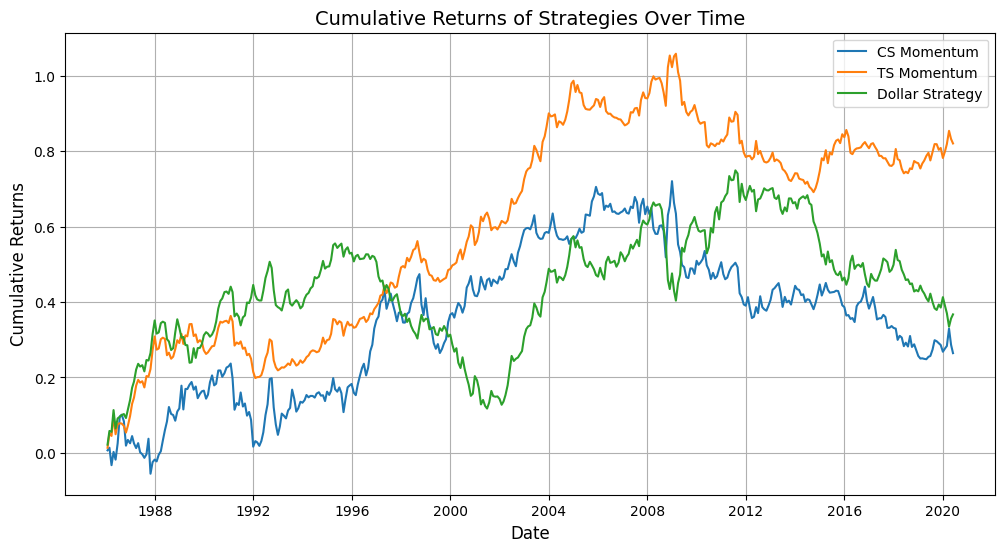

In [9]:
## 2b)

# Lists to store portfolio returns
cs_returns = []
ts_returns = []
dollar_returns = []

# Lookback period
lookback = 12

df = df.dropna()

# Loop over the data, looking 12 months back in order to assess which stocks to purchase a certain month
for t in range(lookback, len(df)):
    # Get past 12-month returns
    past_returns = df[[f'rx_{currency}' for currency in currencies]].iloc[t-lookback:t]
    cumulative_returns = past_returns.sum()

    # CS Momentum Strategy
    # Rank currencies
    ranks = cumulative_returns.rank(ascending=False)
    # Long top 3, short bottom 3
    long_indices = ranks[ranks <= 3].index
    short_indices = ranks[ranks >= 7].index
    weights = {currency: 0 for currency in currencies}
    for idx in long_indices:
        weights[idx.split('_')[1]] = 1/3
    for idx in short_indices:
        weights[idx.split('_')[1]] = -1/3
    # Compute portfolio return
    current_returns = df.iloc[t][[f'rx_{currency}' for currency in currencies]]
    cs_return = sum(weights[currency] * current_returns[f'rx_{currency}'] for currency in currencies)
    cs_returns.append(cs_return)
    
    # TS Momentum Strategy
    weights_ts = {}
    for currency in currencies:
        cum_return = cumulative_returns[f'rx_{currency}']
        position = np.sign(cum_return) # get if negative or positive returns
        weights_ts[currency] = position / len(currencies) # Assign negative weight if previous returns were negative, and vice versa.
    ts_return = sum(weights_ts[currency] * current_returns[f'rx_{currency}'] for currency in currencies)
    ts_returns.append(ts_return)
    
    # Dollar Strategy
    weight_dollar = 1/len(currencies)
    dollar_return = sum(weight_dollar * current_returns[f'rx_{currency}'] for currency in currencies)
    dollar_returns.append(dollar_return)
    
# Convert returns to numpy arrays
cs_returns = np.array(cs_returns)
ts_returns = np.array(ts_returns)
dollar_returns = np.array(dollar_returns)

# Performance metrics
def compute_metrics(returns):
    mu = np.mean(returns) * 12
    sigma = np.std(returns) * np.sqrt(12)
    sharpe_ratio = (mu / sigma)
    # T-statistic
    t_stat = ((mu/12) / (sigma/np.sqrt(12))) * np.sqrt(len(returns))
    return mu, sigma, sharpe_ratio, t_stat

cs_mu, cs_sigma, cs_sharpe, cs_t = compute_metrics(cs_returns)
ts_mu, ts_sigma, ts_sharpe, ts_t = compute_metrics(ts_returns)
dollar_mu, dollar_sigma, dollar_sharpe, dollar_t = compute_metrics(dollar_returns)

# Display results
print("Strategy Performance (annual):")
print(f"CS Momentum: Mean={cs_mu:.4f}, Std Dev={cs_sigma:.4f}, Sharpe Ratio={cs_sharpe:.2f}, t-stat={cs_t:.2f}")
print(f"TS Momentum: Mean={ts_mu:.4f}, Std Dev={ts_sigma:.4f}, Sharpe Ratio={ts_sharpe:.2f}, t-stat={ts_t:.2f}")
print(f"Dollar Strategy: Mean={dollar_mu:.4f}, Std Dev={dollar_sigma:.4f}, Sharpe Ratio={dollar_sharpe:.2f}, t-stat={dollar_t:.2f}")


### Plot
# Convert to cumulative returns
cs_cum_returns = np.cumsum(cs_returns)
ts_cum_returns = np.cumsum(ts_returns)
dollar_cum_returns = np.cumsum(dollar_returns)

# Create time index
time_index = df['Dates'].iloc[lookback:].reset_index(drop=True)

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(time_index, cs_cum_returns, label="CS Momentum")
plt.plot(time_index, ts_cum_returns, label="TS Momentum")
plt.plot(time_index, dollar_cum_returns, label="Dollar Strategy")

plt.title("Cumulative Returns of Strategies Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Returns", fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig("A6_2b_cum_ret_plot.png", dpi = 400)
plt.show()


In [10]:
import numpy as np
import pandas as pd

# 2c) Decomposition

# Shift returns by 12 months to get r_i,t-12
returns_lag12 = returns.shift(12).add_suffix('_lag12')

# Shift returns by -1 month to get r_i,t+1
returns_future = returns.shift(-1).add_suffix('_future')

# Merge lags and future and drop nans
aligned = pd.concat([returns_lag12, returns_future], axis=1).dropna()

# Separate back into lagged and future returns 
returns_lag12_aligned = aligned[[f'rx_{currency}_lag12' for currency in currencies]]
returns_future_aligned = aligned[[f'rx_{currency}_future' for currency in currencies]]

# Calculate the mean of lagged and future returns
mean_lag12 = returns_lag12_aligned.mean()
mean_future = returns_future_aligned.mean()

# Calculate the expectation E[r_j,t-12 * r_i,t+1]
E_rj_t12_r_i_t1 = (returns_lag12_aligned.T @ returns_future_aligned) / len(aligned)

# Calculate the outer product of the means
mean_product = np.outer(mean_lag12, mean_future)

# Calculate the covariance matrix O = E[r_j,t-12 * r_i,t+1] - E[r_j,t-12] * E[r_i,t+1]
O = E_rj_t12_r_i_t1.values - mean_product

# Convert O to a DataFrame
O_df = pd.DataFrame(O, index=[f'{currency}_lag12' for currency in currencies],
                   columns=[f'{currency}_future' for currency in currencies])

# Number of currencies
N = len(currencies)

# Calculate trace of O (sum of diagonal elements)
tr_O = np.trace(O)

# Calculate sum of all elements in O
sum_all = O.sum().sum()

# Calculate sum of cross-serial covariances (excluding diagonal)
sum_cross = sum_all - tr_O

# Calculate Auto and Cross for CS momentum
Auto_CS = tr_O / N**2
Cross_CS = sum_cross / N**2

# Calculate the cross-sectional variance of the mean returns m = Var(r_EW,t-12)
r_EW_t12 = returns_lag12_aligned.mean(axis=1)
s_m_squared = r_EW_t12.var()

# Calculate Mean component for CS
Mean_CS = 0.5 * s_m_squared

# Calculate Total expected return for CS momentum
Total_CS = Auto_CS + Cross_CS + Mean_CS

# Calculate Auto and Mean squared for TS momentum
Auto_TS = tr_O / N
Mean_TS = 0.5 * s_m_squared

# Calculate Total expected return for TS momentum
Total_TS = Auto_TS + Mean_TS

# Display the components
print("\nCross-Sectional Momentum Decomposition:")
print(f"Auto: {Auto_CS:.6f}")
print(f"Cross: {Cross_CS:.6f}")
print(f"Mean: {Mean_CS:.6f}")
print(f"Total: {Total_CS:.6f}")

print("\nTime-Series Momentum Decomposition:")
print(f"Auto: {Auto_TS:.6f}")
print(f"Mean Squared: {Mean_TS:.6f}")
print(f"Total: {Total_TS:.6f}")

## Scale with results from 2b)
cs_std = np.std(cs_returns)

# Compute scaling factors
scaling_factor_CS = cs_mu / Total_CS
scaling_factor_TS = ts_mu / Total_TS

print(f"\nScaling Factor for CS Momentum: {scaling_factor_CS:.6f}")
print(f"Scaling Factor for TS Momentum: {scaling_factor_TS:.6f}")

# Apply scaling to the decomposition components
Scaled_Auto_CS = Auto_CS * scaling_factor_CS
Scaled_Cross_CS = Cross_CS * scaling_factor_CS
Scaled_Mean_CS = Mean_CS * scaling_factor_CS
Scaled_Total_CS = Total_CS * scaling_factor_CS

Scaled_Auto_TS = Auto_TS * scaling_factor_TS
Scaled_Mean_TS = Mean_TS * scaling_factor_TS
Scaled_Total_TS = Total_TS * scaling_factor_TS

# Display the scaled components
print("\nScaled Cross-Sectional Momentum Decomposition:")
print(f"Auto: {Scaled_Auto_CS:.6f}")
print(f"Cross: {Scaled_Cross_CS:.6f}")
print(f"Mean: {Scaled_Mean_CS:.6f}")
print(f"Total: {Scaled_Total_CS:.6f}")

print("\nScaled Time-Series Momentum Decomposition:")
print(f"Auto: {Scaled_Auto_TS:.6f}")
print(f"Mean Squared: {Scaled_Mean_TS:.6f}")
print(f"Total: {Scaled_Total_TS:.6f}")

# Validate the decomposition
print("\nComparison with Part 2(b) Results After Scaling:")
print(f"CS Momentum Average Return (Part 2b): {cs_mu:.6f}")
print(f"CS Momentum Total from Decomposition: {Scaled_Total_CS:.6f}")
print(f"TS Momentum Average Return (Part 2b): {ts_mu:.6f}")
print(f"TS Momentum Total from Decomposition: {Scaled_Total_TS:.6f}")


Cross-Sectional Momentum Decomposition:
Auto: -0.000004
Cross: -0.000018
Mean: 0.000270
Total: 0.000247

Time-Series Momentum Decomposition:
Auto: -0.000037
Mean Squared: 0.000270
Total: 0.000233

Scaling Factor for CS Momentum: 31.092648
Scaling Factor for TS Momentum: 102.431128

Scaled Cross-Sectional Momentum Decomposition:
Auto: -0.000127
Cross: -0.000571
Mean: 0.008382
Total: 0.007683

Scaled Time-Series Momentum Decomposition:
Auto: -0.003767
Mean Squared: 0.027613
Total: 0.023846

Comparison with Part 2(b) Results After Scaling:
CS Momentum Average Return (Part 2b): 0.007683
CS Momentum Total from Decomposition: 0.007683
TS Momentum Average Return (Part 2b): 0.023846
TS Momentum Total from Decomposition: 0.023846
